In [121]:
# Preparing pathing
%load_ext autoreload
%autoreload 2
from titanic_ml import paths
import matplotlib.pyplot as plt
import pandas as pd
from titanic_ml.common.data.eda import summarize_categorical_column, summarize_numerical_column


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [122]:
from titanic_ml.data import load_train_data

df = load_train_data()
print(df.head())
TARGET = "Survived"

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [123]:
# Length of string columns
length = df['Embarked'].str.len().describe()
print(f"Length of 'Embarked':\n{length}")

'''
This reveals:

free text
codes
IDs
malformed entries

Example:

all length 2 → state codes
all length 36 → UUIDs
huge variance → real text

Very powerful for schema discovery.
'''


# Cardinality: number of unique values / total rows
cardinality = df['Embarked'].nunique(dropna=True) / len(df['Embarked'])
print(f"Cardinality of 'Embarked': {cardinality:.2%}")

# Ratio	Meaning
'''
Very low = categorical
Medium = mixed
Very high = ID-like/free text

Example:

gender → 0.00002
country → 0.01
customer_id → 1.0

This immediately reveals:

IDs
UUIDs
text fields
columns unsuitable for one-hot encoding
'''

# Dominance Ratio
top_freq = df['Embarked'].value_counts(dropna=False, normalize=True).iloc[0]
print(f"Dominance Ratio of 'Embarked': {top_freq:.2%}")

'''
Dominance Ratio	Meaning
Very low = no dominant category
Medium = some dominance
Very high = one category dominates

useful for detecting useless columns.

If:

one value = 99%
column may be useless

Example:
"ACTIVE" repeated everywhere
'''

print()
print()
# Memory usage
df.memory_usage(deep=True)
print(f"Total memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Column health summary
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_%': df.isna().mean() * 100,
    'unique': df.nunique(),
    'cardinality_%': df.nunique() / len(df) * 100,
    'top_value': df.apply(lambda s: s.value_counts(dropna=False).idxmax()),
    'dominance_%': df.apply(lambda s: s.value_counts(dropna=False, normalize=True).iloc[0] * 100),
    'bottom_value': df.apply(lambda s: s.value_counts(dropna=False).idxmin()),
})

summary = summary.sort_values(
    by='missing_%',
    ascending=False
)

print(summary)


Length of 'Embarked':
count    889.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: Embarked, dtype: float64
Cardinality of 'Embarked': 0.34%
Dominance Ratio of 'Embarked': 72.28%


Total memory usage: 315.03 KB
               dtype  missing_%  unique  cardinality_%            top_value  \
Cabin         object  77.104377     147      16.498316                  NaN   
Age          float64  19.865320      88       9.876543                  NaN   
Embarked      object   0.224467       3       0.336700                    S   
PassengerId    int64   0.000000     891     100.000000                  891   
Name          object   0.000000     891     100.000000  Dooley, Mr. Patrick   
Pclass         int64   0.000000       3       0.336700                    3   
Survived       int64   0.000000       2       0.224467                    0   
Sex           object   0.000000       2       0.224467                 male   
Parch        

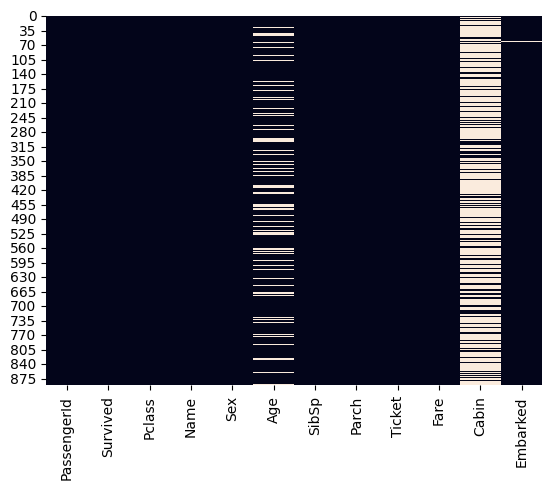

In [124]:
import seaborn as sns
# Missing Values Heatmap
sns.heatmap(df.isna(), cbar=False)

'''
This immediately shows:
missingness structure
grouped missing values
data pipeline problems
'''
plt.show()

<Axes: >

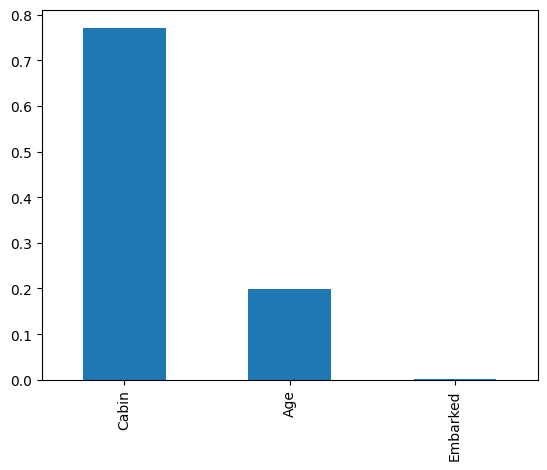

In [125]:
# Missing Percentage Barplot
missing = df.isna().mean().sort_values(ascending=False)

missing[missing > 0].plot.bar()

<Axes: >

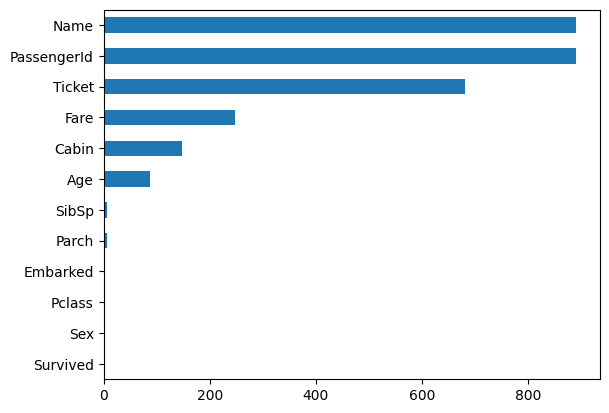

In [126]:
# cardinality barplot
df.nunique().sort_values().plot.barh()

In [127]:
def summarize_categorical_column(series, max_display=20):
    # Count frequencies including NaN
    counts = series.value_counts(dropna=False)

    # Percentages
    percents = (
        series.value_counts(dropna=False, normalize=True) * 100
    ).round(2)

    # Build summary table
    summary = pd.DataFrame({
        'count': counts,
        'percent': percents
    })

    # Renaming NA/None to 'MISSING' for better readability
    summary = summary.rename(index={pd.NA: 'MISSING', None: 'MISSING'})

    # If small enough, show everything
    if len(summary) <= max_display:
        return summary

    # Otherwise show top/bottom
    top_n = max_display // 2

    truncated = pd.concat([
        summary.head(top_n),
        pd.DataFrame(
            {'count': ['...'], 'percent': ['...']},
            index=['...']
        ),
        summary.tail(top_n)
    ])

    return truncated

def summarize_numerical_column(df):
    return df.describe(include=['number'])

def deep_describe(df):

    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    numerical_cols = df.select_dtypes(include=['number']).columns

    print('Categorical columns summary:')
    for col in categorical_cols:
        print(f'\n=== {col} ===')
        print(summarize_categorical_column(df[col]))
    
    print('Numerical columns summary:')
    for col in numerical_cols:
        print(f'\n=== {col} ===')
        print(summarize_numerical_column(df[col]))

def summarize_dataframe(df):
    summary = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_%': df.isna().mean() * 100,
    'unique': df.nunique(),
    'cardinality_%': df.nunique() / len(df) * 100,
    'top_value': df.apply(lambda s: s.value_counts(dropna=False).idxmax()),
    'dominance_%': df.apply(lambda s: s.value_counts(dropna=False, normalize=True).iloc[0] * 100),
    'bottom_value': df.apply(lambda s: s.value_counts(dropna=False).idxmin()),
    })

    summary = summary.sort_values(
        by='missing_%',
        ascending=False
    )

    print(summary)

summarize_dataframe(df)
deep_describe(df)

               dtype  missing_%  unique  cardinality_%            top_value  \
Cabin         object  77.104377     147      16.498316                  NaN   
Age          float64  19.865320      88       9.876543                  NaN   
Embarked      object   0.224467       3       0.336700                    S   
PassengerId    int64   0.000000     891     100.000000                  891   
Name          object   0.000000     891     100.000000  Dooley, Mr. Patrick   
Pclass         int64   0.000000       3       0.336700                    3   
Survived       int64   0.000000       2       0.224467                    0   
Sex           object   0.000000       2       0.224467                 male   
Parch          int64   0.000000       7       0.785634                    0   
SibSp          int64   0.000000       7       0.785634                    0   
Fare         float64   0.000000     248      27.833895                 8.05   
Ticket        object   0.000000     681      76.4309

In [128]:
import pandas as pd


def format_missing_index(index):
    return ["MISSING" if pd.isna(idx) else idx for idx in index]


def summarize_categorical_column(series, max_display=20):
    counts = series.value_counts(dropna=False)
    percents = (series.value_counts(dropna=False, normalize=True) * 100).round(2)

    summary = pd.DataFrame({
        "count": counts,
        "percent": percents,
    })

    summary.index = format_missing_index(summary.index)

    if len(summary) <= max_display:
        return summary

    top_n = max_display // 2

    truncated = pd.concat([
        summary.head(top_n),
        pd.DataFrame(
            {"count": ["..."], "percent": ["..."]},
            index=["..."],
        ),
        summary.tail(top_n),
    ])

    return truncated


def summarize_numerical_column(series):
    summary = series.describe()

    extra = pd.Series({
        "missing_count": series.isna().sum(),
        "missing_%": round(series.isna().mean() * 100, 2),
        "skew": series.skew(),
        "kurtosis": series.kurtosis(),
    })

    return pd.concat([summary, extra])


def safe_top_value(series):
    counts = series.value_counts(dropna=False)
    if counts.empty:
        return None
    value = counts.index[0]
    return "MISSING" if pd.isna(value) else value


def safe_bottom_value(series):
    counts = series.value_counts(dropna=False)
    if counts.empty:
        return None
    value = counts.index[-1]
    return "MISSING" if pd.isna(value) else value


def summarize_dataframe(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null_count": df.notna().sum(),
        "missing_count": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=False),
        "cardinality_%": (df.nunique(dropna=False) / len(df) * 100).round(2),
        "top_value": df.apply(safe_top_value),
        "dominance_%": df.apply(
            lambda s: round(s.value_counts(dropna=False, normalize=True).iloc[0] * 100, 2)
            if not s.empty else None
        ),
        "bottom_value": df.apply(safe_bottom_value),
    })

    return summary.sort_values(by="missing_%", ascending=False)


def display_dataframe_description(df, max_display=20):
    categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns
    numerical_cols = df.select_dtypes(include=["number"]).columns

    print("DataFrame Summary:")
    print(summarize_dataframe(df))
    print("="*60)
    print("Categorical columns summary:")
    for col in categorical_cols:
        print(f"\n=== {col} ===")
        print(summarize_categorical_column(df[col], max_display=max_display))
    print("="*60)
    print("\nNumerical columns summary:")
    for col in numerical_cols:
        print(f"\n=== {col} ===")
        print(summarize_numerical_column(df[col]))

In [129]:
display_dataframe_description(df)

DataFrame Summary:
               dtype  non_null_count  missing_count  missing_%  unique  \
Cabin         object             204            687      77.10     148   
Age          float64             714            177      19.87      89   
Embarked      object             889              2       0.22       4   
PassengerId    int64             891              0       0.00     891   
Name          object             891              0       0.00     891   
Pclass         int64             891              0       0.00       3   
Survived       int64             891              0       0.00       2   
Sex           object             891              0       0.00       2   
Parch          int64             891              0       0.00       7   
SibSp          int64             891              0       0.00       7   
Fare         float64             891              0       0.00     248   
Ticket        object             891              0       0.00     681   

             cardi

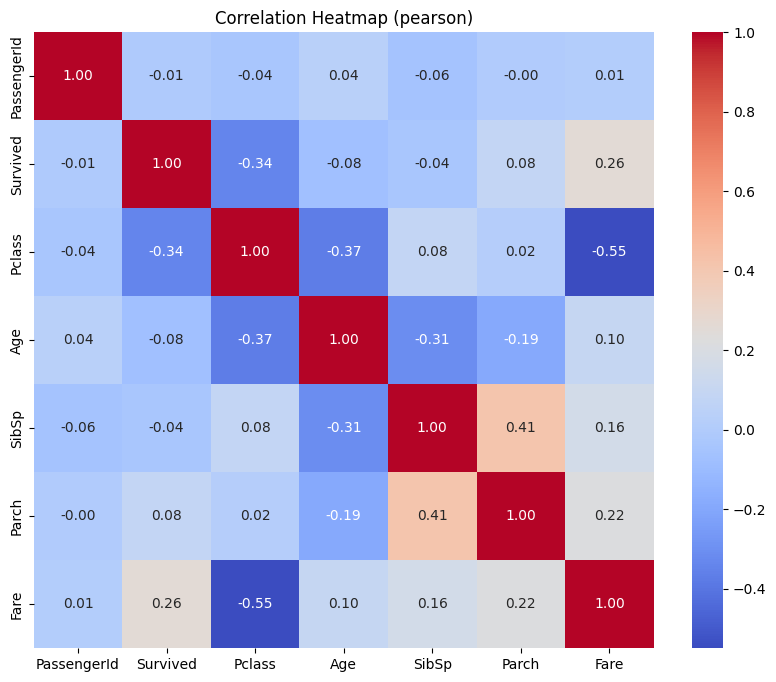


Absolute correlation of features with target 'Survived':
             Survived
Pclass      -0.338481
Fare         0.257307
Parch        0.081629
Age         -0.077221
SibSp       -0.035322
PassengerId -0.005007


In [130]:
def correlation_analysis(
    df,
    method="pearson",
    target=None,
):
    numerical_df = df.select_dtypes(include=['number'])
    Cor = numerical_df.corr(method=method)
    plt.figure(figsize=(10, 8))
    sns.heatmap(Cor, annot=True, cmap='coolwarm',fmt=".2f")
    plt.title(f"Correlation Heatmap ({method})")
    plt.show()

    if target is not None and target in Cor.columns:
        target_corr = (
            Cor[target]
            .drop(target)
            .sort_values(key=lambda s: s.abs(), ascending=False)
            ).to_frame()
        print(f"\nAbsolute correlation of features with target '{target}':")
        print(target_corr)

correlation_analysis(df, method="pearson", target=TARGET)

In [131]:
# %reload_ext autoreload
from titanic_ml.common.data.eda import run_eda # ,show_examples
Eda = run_eda(df, target=TARGET, ) #display_advanced=True
# print(show_examples(df, column="Embarked", value="S", max_examples=5))

Dataframe Health
rows                                                                  891
columns                                                                12
duplicate_rows                                                          0
duplicate_%                                                           0.0
rows_with_missing                                                     708
rows_with_missing_%                                                 79.46
total_missing_values                                                  866
dataFrame_columns       [PassengerId, Survived, Pclass, Name, Sex, Age...
dtype: object
DataFrame Summary:
               dtype  non_null_count  missing_count  missing_%  unique  \
PassengerId    int64             891              0       0.00     891   
Survived       int64             891              0       0.00       2   
Pclass         int64             891              0       0.00       3   
Name          object             891              0       0.00